In [3]:
#Importamos las bibliotecas necesarias para el análisis de datos y visualización
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter
import seaborn as sns 

# Paquete necesario para trabajar con fechas 
import datetime , os 

In [4]:
# Cargas carpeta de archivo 
os.chdir("C:/Users/HP/Desktop/ESTUDIO/Proyectos/Steam Juegos")
# Cargamos la carpeta
steam = pd.read_csv("steam_top_games_2026.csv")
steam #Verificamos la tabla cargada 


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,...,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy",...,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie",...,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation",...,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation",...,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,1590910,Forgive Me Father,"Apr 7, 2022",False,19.99,False,0,Byte Barrel,Fulqrum Publishing,"Action, Indie",...,"500,000 .. 1,000,000",204,0,106,61,0,1,20,Forgive Me Father is a dark retro horror FPS s...,https://shared.akamai.steamstatic.com/store_it...
1491,1693970,PARTY RUSH!!,"Mar 23, 2022",False,9.99,False,0,SECHAN,HIKE Inc.,"Adventure, Casual, Indie, RPG",...,"200,000 .. 500,000",0,0,0,0,0,1,15,"Here we present, a cynical RPG with close to 1...",https://shared.akamai.steamstatic.com/store_it...
1492,1225330,NBA 2K21,"Sep 4, 2020",False,0.00,False,0,Visual Concepts,2K,"Simulation, Sports",...,"1,000,000 .. 2,000,000",6563,0,4090,148,0,0,50,NOTE: All multiplayer servers for NBA 2K21 wil...,https://shared.akamai.steamstatic.com/store_it...
1493,764030,Realm Revolutions,"Jan 5, 2018",False,0.00,True,0,Aleksandr Golovkin,Aleksandr Golovkin,Free To Play,...,"200,000 .. 500,000",20080,0,4114,57,0,0,0,Earning coins and resources is more fun than e...,https://shared.akamai.steamstatic.com/store_it...


In [5]:
#  # LIMPIEZA Y TIPOS DE DATOS # #
# Renombramos las columnas para facilitar su comprensión y análisis
steam.rename(columns = {"name": "nombres",
    "release_date": "fecha_lanzamiento",
    "price_usd": "precio_usd",
    "is_free": "es_gratis",
    "estimated_owners": "cantidad_usuarios",
    "genres": "generos",
    "developer": "desarrolladora",
    "publisher": "compañia",
    "required_age": "edad_requerida"}, inplace = True) 
# Seleccionamos las columnas que utilizaremos 
steam = steam[["nombres", "fecha_lanzamiento", "precio_usd", "es_gratis", "cantidad_usuarios", "generos", "desarrolladora", "compañia", "edad_requerida"]] 
steam.head() # Verificamos los cambios realizados en la tabla

steam.dtypes # Verificamos los tipos de datos de cada columna para identificar posibles errores o inconsistencias

steam.isnull().sum() # Verificamos si hay valores nulos en la tabla para determinar si es necesario realizar limpieza de datos adicional

steam[steam.isnull().any(axis = 1 )] # Mostramos las filas que contienen valores nulos para analizar su impacto en el análisis de datos
# Quitar comas y espacios
steam["cantidad_usuarios"] = steam["cantidad_usuarios"].str.replace(",", "").str.strip()

# Paso 1: limpiar texto
steam["cantidad_usuarios"] = (
    steam["cantidad_usuarios"]
    .str.replace(",", "", regex=False)   # quitar comas
    .str.replace("..", "-", regex=False) # reemplazar ".." por "-"
    .str.strip()
)

# Paso 2: separar en min y max
rangos = steam["cantidad_usuarios"].str.split("-")
steam["usuarios_min"] = pd.to_numeric(rangos.str[0], errors="coerce")
steam["usuarios_max"] = pd.to_numeric(rangos.str[1], errors="coerce")

# Paso 3: si no hay max, usar min
steam["usuarios_max"] = steam["usuarios_max"].fillna(steam["usuarios_min"])

# Paso 4: calcular promedio
steam["usuarios_promedio"] = (steam["usuarios_min"] + steam["usuarios_max"]) / 2

steam = steam.drop(columns = ['cantidad_usuarios' , 'es_gratis']) # Borramos la columna que estaba en string
steam['usuarios_promedio'].isnull().sum()
print(steam["usuarios_promedio"].mean())

steam["usuarios_promedio"] = steam["usuarios_promedio"].fillna(1655033.55704698) # imputacion de valor faltante por el promedio. 

steam.head()



1655033.55704698


,nombres,fecha_lanzamiento,precio_usd,generos,desarrolladora,compañia,edad_requerida,usuarios_min,usuarios_max,usuarios_promedio
0,Outward Definitive Edition,"May 17, 2022",4.79,RPG,Nine Dots Studio,"Prime Matter, Deep Silver",0,1000000.0,2000000.0,1500000.0
1,Gorky 17,"Sep 27, 2013",9.99,"RPG, Strategy",Metropolis Software,TopWare Interactive,17,200000.0,500000.0,350000.0
2,Secret in Story,"Jun 19, 2017",0.89,"Adventure, Indie",Naivus Luo,Naivus Luo,0,2000000.0,5000000.0,3500000.0
3,懒人修仙传,"Nov 14, 2018",3.99,"Casual, Indie, RPG, Simulation",托更的修罗,托更的修罗,0,200000.0,500000.0,350000.0
4,Train Station Renovation,"Oct 1, 2020",18.99,"Casual, Indie, Simulation",Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...",0,200000.0,500000.0,350000.0


### Tratamiento de valores faltantes
- **Fechas de lanzamiento**: completadas manualmente cuando fue posible; en los casos restantes se imputó "Sin Datos".
- **Cantidad de usuarios**: se completó con valores promedio representativos. (LO COMPLETO CON LOS EL PROMEDIO )
- **Géneros**: se imputó "Sin Datos" en los casos faltantes.
- **Desarrolladora y compañía**: se imputó "Desconocida" o "Sin Datos" según corresponda.

ES LO QUE DEBO HACER.

In [6]:
# Agregamos los datos FALTANTES #
    # COMENZAMOS CON LAS FECHAS #
steam.loc[steam['nombres']== 'Sniper Elite V2' , 'fecha_lanzamiento'] = 'May 1,2012'
steam.loc[steam['nombres']== '3DMark' , 'fecha_lanzamiento'] = 'Feb 4 , 2013'
steam.loc[steam['nombres']== 'Mark of the Ninja' , 'fecha_lanzamiento'] = 'Oct 16,2012'
steam.loc[steam['nombres']== 'NBA 2K18' , 'fecha_lanzamiento'] = 'Sep 15,2017'
steam.loc[steam['nombres']== 'Sleeping Dogs' , 'fecha_lanzamiento'] = 'Aug 14,2012'
steam.loc[steam['nombres']== 'Operation Flashpoint: Red River' , 'fecha_lanzamiento'] = 'Apr 21,2011'

    # DESARROLLADORA #
steam.loc[steam['nombres'] == 'Septerra Core' , 'desarrolladora'] = 'Valkyrie Studios'
steam.loc[steam['nombres'] == ' Daikatana' , 'desarrolladora'] = 'Ion Storm'
steam.loc[steam['nombres'] == 'Portal 2 Sixense Pack' , 'desarrolladora'] = 'Sixense Studios'
steam.loc[steam['nombres'] == 'Minimum' , 'desarrolladora'] = 'TimeGate Studios'
steam.loc[steam['nombres'] == 'Secret of Magia' , 'desarrolladora'] = 'Lunatoid'

    # COMPAÑIA #
steam.loc[steam['nombres'] == 'Little Square Things' , 'compañia'] = 'gbelo Games'
steam.loc[steam['nombres'] == 'Operation Harsh Doorstop' , 'compañia'] = 'Drakeling Labs'
steam.loc[steam['nombres'] == 'Unreal Gold' , 'compañia'] = 'Epic Games'
steam.loc[steam['nombres'] == 'AudioSurf' , 'compañia'] = 'Audiosuf LLC'
steam.loc[steam['nombres'] == 'Marauders' , 'compañia'] = 'Team17'
steam.loc[steam['nombres'] == 'Soccer Manager 2022' , 'compañia'] = 'Invincibles Studio Ltd'
steam.loc[steam['nombres'] == 'Aimtastic' , 'compañia'] = 'Pixel Pointer Studios'

    # USUARIOS #
#steam = steam.astype({'cantidad_usuarios': float})
#media_usuarios = steam['cantidad_usuarios'].mean()
#steam # Verificamos los cambios realizados en la tabla después de agregar los datos faltantes
#print(steam.dtypes)


 Cálculos principales
1. Top 20 juegos más comprados con su respectivo precio (ordenar de mayor a menor).
2. Top 20 juegos Free to Play más descargados (precio = 0, ordenar por compras).
3. Juegos con edad requerida → analizar descripciones y géneros para sacar conclusiones (sin gráfico).
4. Empresas con más ventas → agrupar por empresa y sumar compras (si hay ingresos, comparar también por ventas monetarias).
5. Análisis de precios con NumPy:
6. a-Juego más caro (máximo).
7. b-Juego más barato (mínimo).
8. c-Promedio de precios.
9. d-Desviación estándar de precios.


In [7]:
# GENERAMOS UN COPIA #
steam_copy = steam 

# top 20 juegos mas comprados
top_20_buy = steam_copy[steam_copy['precio_usd']!= 0.00].sort_values('usuarios_promedio',ascending = False ).head(20)
top_20_buy

# Top 20 juegos mas descargados gratis
top_20_free = top_20 = steam_copy[steam_copy['precio_usd']== 0.00].sort_values('usuarios_promedio',ascending = False ).head(20)
top_20_free

# Top 25 juegos edad requerida. 
top_25_17 = steam_copy[steam_copy['edad_requerida'] <= 17].sample(12)
top_25_18 = steam_copy[steam_copy['edad_requerida'] > 17].sort_values('edad_requerida' , ascending= False)
top_25_17
top_25_18

#Top 10 juegos mas caros
top_buy_caros = steam_copy[steam_copy['precio_usd']!= 0.00].sort_values('precio_usd',ascending = False ).head(10)
top_buy_caros

# Compañia = ventas , cantidad de usuarios. 
steam_copy['ingresos'] = steam_copy['usuarios_promedio'] * steam_copy['precio_usd']
compañia = steam_copy.groupby('compañia')[['usuarios_promedio' , 'ingresos']].sum().reset_index()
compañia = compañia.sort_values('usuarios_promedio' , ascending= False ).head(10)
compañia

,compañia,usuarios_promedio,ingresos
839,Valve,2.150000e+08,4.170750e+08
48,Amazon Game Studios,7.665503e+07,0.000000e+00
721,Smartly Dressed Games,7.500000e+07,0.000000e+00
240,Electronic Arts,5.795000e+07,1.183149e+09
444,Larian Studios,4.250000e+07,2.183950e+09
873,Xbox Game Studios,3.875000e+07,3.180875e+08
828,Ubisoft,3.795000e+07,9.384925e+08
122,"CAPCOM Co., Ltd.",3.685000e+07,1.245132e+09
91,Behaviour Interactive Inc.,3.535000e+07,7.017465e+08
263,Facepunch Studios,3.500000e+07,1.399650e+09


In [8]:
## GUARDAR EN EXCEL ##
with pd.ExcelWriter('analisis_steam.xlsx') as writer:
    top_20_buy.to_excel(writer, sheet_name='Top 20 Pagos', index=False)
    top_20_free.to_excel(writer, sheet_name='Top 20 Free', index=False)
    top_25_17.to_excel(writer, sheet_name='Edad <= 17', index=False)
    top_25_18.to_excel(writer, sheet_name='Edad > 17', index=False)
    top_buy_caros.to_excel(writer, sheet_name='Top 10 Caros', index=False)
    compañia.to_excel(writer, sheet_name='Top Compañías', index=False)



GENERAR ESTADISTICA DESCRIPTIVA , para : sí, ese bloque de análisis era justamente para responder esas cuatro preguntas clave sobre precios y darle soporte a tus visualizaciones y conclusiones en el proyecto Steam.
1. Juego más caro → te da el valor máximo de la columna precio_usd.
2. Juego más barato → te da el valor mínimo.
3. Promedio de precios → te muestra la media aritmética, útil para ver el “precio típico” de los juegos.
4. Desviación estándar → te indica la dispersión de los precios respecto al promedio, o sea si los precios están muy concentrados o muy variados.

In [9]:
# ESTADISTICA DESCRIPTIVA c/ NUMPY #

precio_max = np.max(steam_copy['precio_usd'])
precio_min = np.min(steam_copy['precio_usd'])
promedio_precio = np.mean(steam_copy['precio_usd'])
dv_precio = np.std(steam_copy['precio_usd'])
mediana = np.median(steam_copy['precio_usd'])

# Genero un DataFrame con los resultados de la estadística descriptiva
resumen_precio = pd.DataFrame({
    'Precio Maximo': [precio_max],
    'Precio Minimo': [precio_min],
    'Promedio Precio': [promedio_precio],
    'Desviacion Estandar': [dv_precio],
    'Mediana': [mediana]
})
resumen_precio



,Precio Maximo,Precio Minimo,Promedio Precio,Desviacion Estandar,Mediana
0,149.99,0.0,12.086763,13.961761,8.99


4. VISUALIZACIONES: 
   A. Barras Vertical
   B. Barras Horizontal
   C. Barras Comparativo
   D. Boxplot
   E. Violin Plot
   F. Histograma

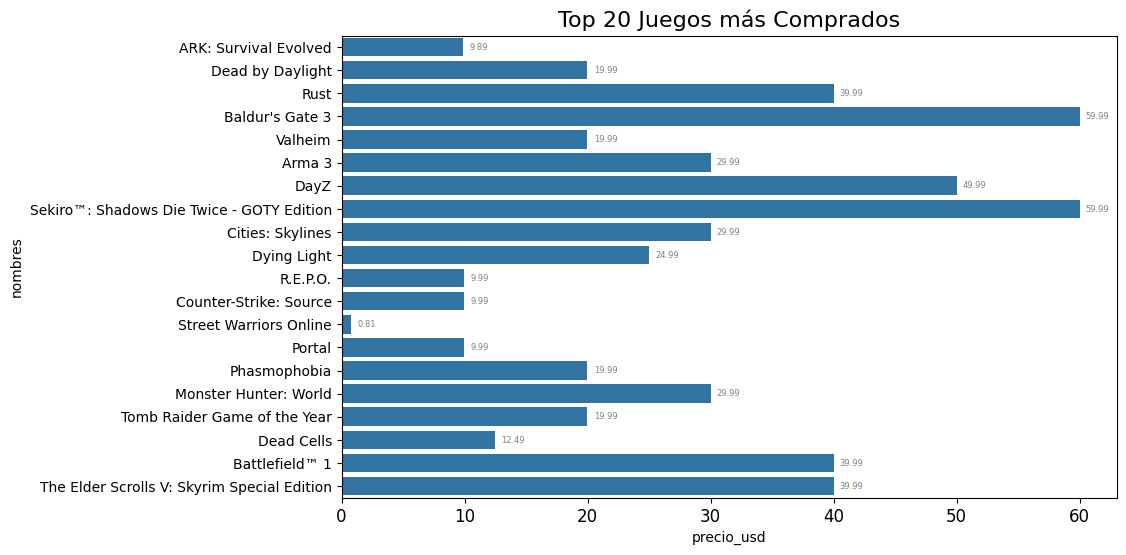

In [10]:
# Barras Vertical : Top 20 juegos mas comprados
plt.figure(figsize=(10,6))   # más ancho para que entren los nombres
sns.barplot(x = 'precio_usd' , y = 'nombres' , data = top_20_buy)
plt.title('Top 20 Juegos más Comprados', fontsize=16 , color = "Black")
plt.xticks(fontsize=12)

# Mostrar todos los valores afuera de las barra.
for i , (valores , nombres) in enumerate(zip(top_20_buy['precio_usd'], top_20_buy['nombres'])):
    plt.text(valores + 0.5, i, f'{valores:.2f}', va='center', fontsize=6, color='gray')

#plt.figtext(0.05, 0.02,
        #    f'Máx: {precio_max:.2f} | Mín: {precio_min:.2f} | Prom: {promedio_precio:.2f} | Std: {dv_precio:.2f} | Mediana: {mediana:.2f}',
         #   ha='right', fontsize=9, color='darkblue',
          #  bbox=dict(facecolor='lightgray', alpha=0.3))

plt.show()

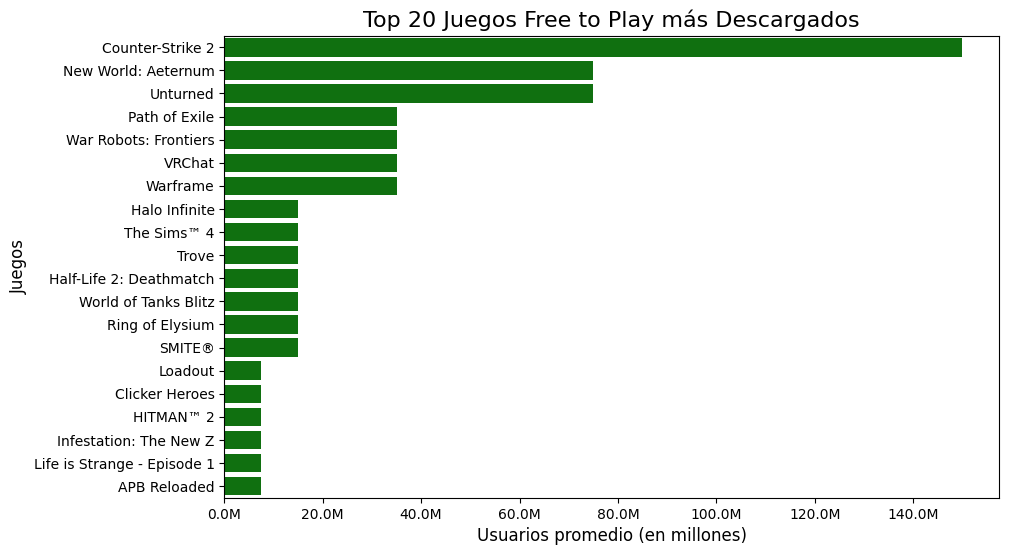

In [11]:
# BARRAS HORIZONTAL: Top 20 juegos Free to Play más descargados.
    # Formatear eje X para mostr5as valores en millones 

from ast import Lambda
plt.figure(figsize=(10,6))   # más ancho para que entren los nombres
sns.barplot(x='usuarios_promedio', y='nombres', data=top_20_free , color = 'green')

formatter = FuncFormatter(lambda x , _: f'{int(x/1e6):.1f}M')  # Formato en millones}')
plt.gca().xaxis.set_major_formatter(formatter)

plt.title('Top 20 Juegos Free to Play más Descargados', fontsize=16, color="black")
plt.xlabel('Usuarios promedio (en millones)', fontsize=12)
plt.ylabel('Juegos', fontsize=12)

plt.show()

In [12]:
compañia

,compañia,usuarios_promedio,ingresos
839,Valve,2.150000e+08,4.170750e+08
48,Amazon Game Studios,7.665503e+07,0.000000e+00
721,Smartly Dressed Games,7.500000e+07,0.000000e+00
240,Electronic Arts,5.795000e+07,1.183149e+09
444,Larian Studios,4.250000e+07,2.183950e+09
873,Xbox Game Studios,3.875000e+07,3.180875e+08
828,Ubisoft,3.795000e+07,9.384925e+08
122,"CAPCOM Co., Ltd.",3.685000e+07,1.245132e+09
91,Behaviour Interactive Inc.,3.535000e+07,7.017465e+08
263,Facepunch Studios,3.500000e+07,1.399650e+09


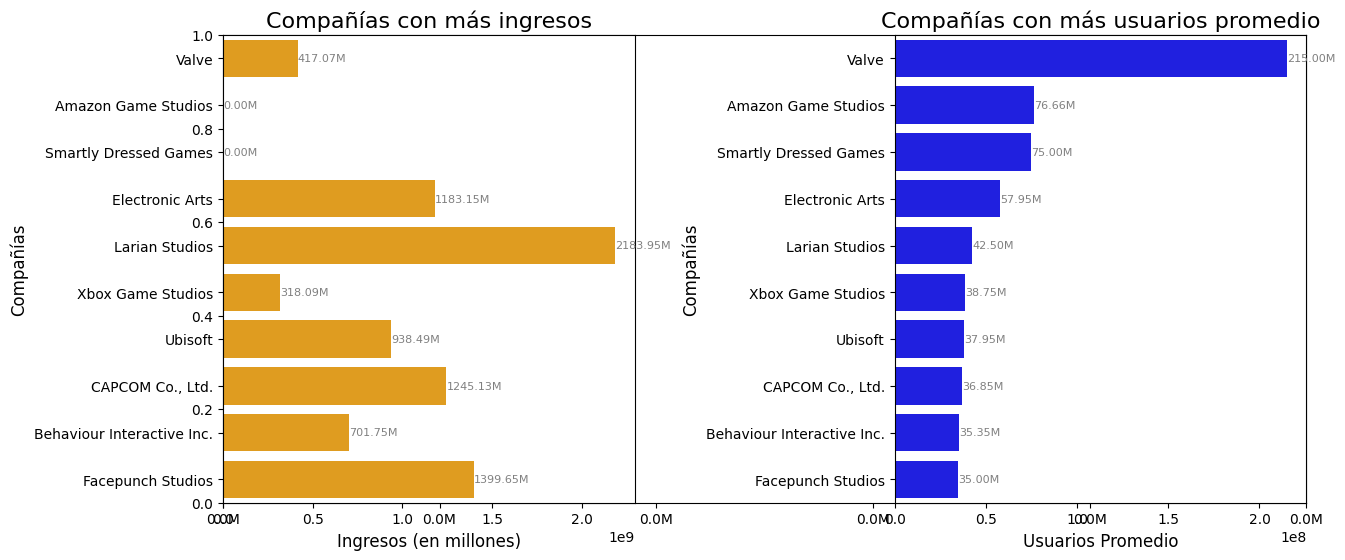

In [13]:
# GRAFICO de BARRAS HORIZONTAL: "Empresas con mas ventas "
plt.figure(figsize=(14,6))   # más ancho para que entren los nombres
# Formatear en millones con decimales
formatter_millones = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
# Aplicar al eje X del subplot actual
plt.gca().xaxis.set_major_formatter(formatter_millones)

# SubPlot 1: Compañías con más ingresos
plt.subplot(1,2,1)
sns.barplot(y='compañia', x='ingresos' , data=compañia, color = 'orange')
plt.title('Compañías con más ingresos', fontsize=16, color="black")
plt.xlabel('Ingresos (en millones)', fontsize=12)
plt.ylabel('Compañías', fontsize=12)
# Mostrar todos los valores afuera de las barra.
for i , (ingresos , empresa) in enumerate(zip(compañia['ingresos'], compañia['compañia'])):
    plt.text(ingresos + 0.5, i, f'{ingresos/1e6:.2f}M', va='center', fontsize=8, color='gray')
    
# Subplot 2: Compañías con más usuarios promedio
plt.subplot(1,2,2)
sns.barplot(y='compañia', x='usuarios_promedio' , data=compañia, color = 'blue')
plt.title('Compañías con más usuarios promedio', fontsize=16, color="black")
plt.xlabel('Usuarios Promedio', fontsize=12)
plt.ylabel('Compañías', fontsize=12)
for i , (usuarios , empresa) in enumerate(zip(compañia['usuarios_promedio'], compañia['compañia'])):
    plt.text(usuarios + 0.5, i, f'{usuarios/1e6:.2f}M', va='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

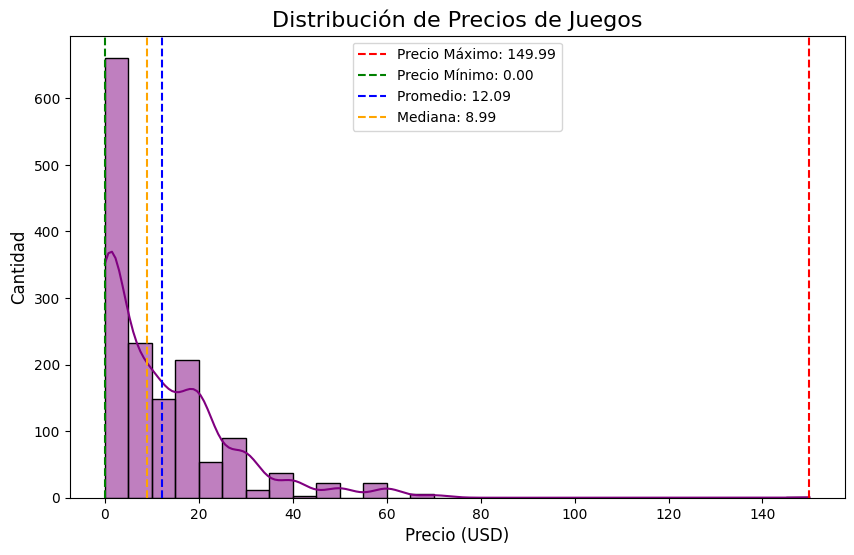

In [14]:
# HISTOGRAMA: distribucion de precios de los juegos. 
plt.figure(figsize=(10,6))
sns.histplot(steam_copy['precio_usd'], bins=30, kde=True, color='purple')
plt.title('Distribución de Precios de Juegos', fontsize=16, color="black")
plt.ylabel('Cantidad', fontsize=12)
plt.xlabel('Precio (USD)', fontsize=12)
plt.axvline(x=precio_max, color='red', linestyle='--', label=f'Precio Máximo: {precio_max:.2f}')
plt.axvline(x=precio_min, color='green', linestyle='--', label=f'Precio Mínimo: {precio_min:.2f}')
plt.axvline(x=promedio_precio, color='blue', linestyle='--', label=f'Promedio: {promedio_precio:.2f}')
plt.axvline(x=mediana, color='orange', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.legend()
plt.show()


Compañia con mas ingresos: Larian Studios
Compañia con mas usuarios promedio: Valve


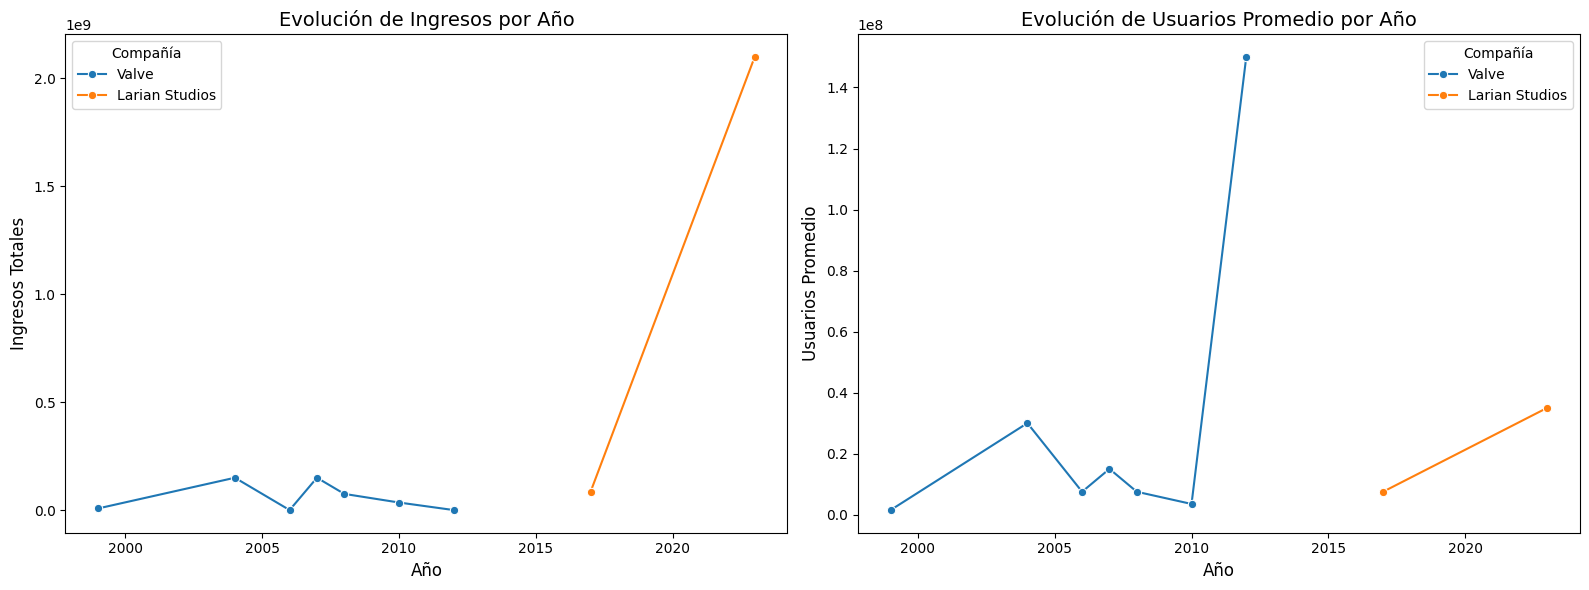

In [15]:
# GRAFICO LINEAL: Evolucion de la compañia con mas ventas a lo largo del tiempo. Y la que contiene mas usuarios promedio.

# Convertir fechas -> IMPORTANTE: se especifica format='mixed' porque sin esto, pandas
# intenta adivinar el formato mirando las primeras filas y falla en la mayoria (bug detectado: 1366 de 1495 fechas se perdian)
steam_copy['fecha_lanzamiento'] = pd.to_datetime(steam_copy['fecha_lanzamiento'], format='mixed', dayfirst=False, errors='coerce')

# Identificar la empresa con mas ingresos totales y la que tiene mas usuarios promedio totales
compania_total = steam_copy.groupby('compañia')[['usuarios_promedio', 'ingresos']].sum().reset_index()
empresa_ingresos = compania_total.loc[compania_total['ingresos'].idxmax(), 'compañia']
empresa_usuarios = compania_total.loc[compania_total['usuarios_promedio'].idxmax(), 'compañia']

print(f'Compañia con mas ingresos: {empresa_ingresos}')
print(f'Compañia con mas usuarios promedio: {empresa_usuarios}')

# Filtrar solo esas dos empresas
datos_filtrados = steam_copy[steam_copy['compañia'].isin([empresa_ingresos, empresa_usuarios])]

# Agrupar por año y compañia
evolucion = datos_filtrados.groupby([datos_filtrados['fecha_lanzamiento'].dt.year, 'compañia'])[['ingresos', 'usuarios_promedio']].sum().reset_index()
evolucion.rename(columns={'fecha_lanzamiento': 'año'}, inplace=True)

# Grafico con dos paneles: evolucion de ingresos y evolucion de usuarios promedio
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.lineplot(data=evolucion, x='año', y='ingresos', hue='compañia', marker='o', ax=axes[0])
axes[0].set_title('Evolución de Ingresos por Año', fontsize=14, color='black')
axes[0].set_xlabel('Año', fontsize=12)
axes[0].set_ylabel('Ingresos Totales', fontsize=12)
axes[0].legend(title='Compañía')

sns.lineplot(data=evolucion, x='año', y='usuarios_promedio', hue='compañia', marker='o', ax=axes[1])
axes[1].set_title('Evolución de Usuarios Promedio por Año', fontsize=14, color='black')
axes[1].set_xlabel('Año', fontsize=12)
axes[1].set_ylabel('Usuarios Promedio', fontsize=12)
axes[1].legend(title='Compañía')

plt.tight_layout()
plt.show()
